In [46]:
import pandas as pd

df = pd.read_csv("medical_appointment_no_shows.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [47]:
df.info()
df["No-show"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


No-show
No     88208
Yes    22319
Name: count, dtype: int64

In [48]:
## Exploratory Data Analysis (EDA)
# We analyze class distribution and basic relationships between features and the target.

In [49]:
df["No-show"].value_counts(normalize=True)

No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

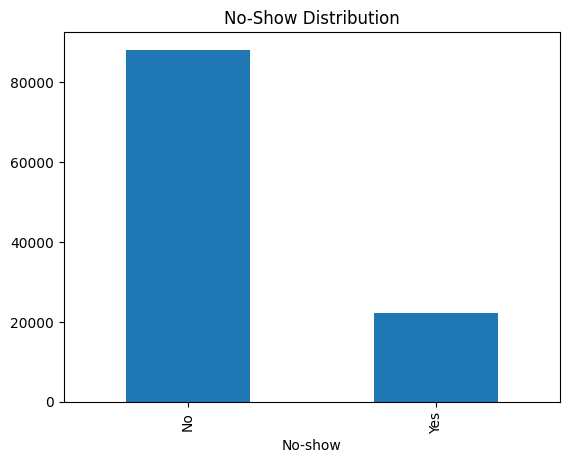

In [50]:
import matplotlib.pyplot as plt

df["No-show"].value_counts().plot(kind="bar", title="No-Show Distribution")
plt.show()

In [51]:
# Relationship with SMS reminders
pd.crosstab(df["SMS_received"], df["No-show"], normalize="index")

No-show,No,Yes
SMS_received,,
0,0.832967,0.167033
1,0.724255,0.275745


In [52]:
## Data Preprocessing & Feature Engineering
# We clean the dataset, engineer useful features, and prepare it for model training.

In [53]:
# Drop IDs
df = df.drop(columns=["PatientId", "AppointmentID"], errors="ignore")

In [54]:
# Convert to datetime
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

In [55]:
# New Column: Waiting Days
df["WaitingDays"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days
df["WaitingDays"] = df["WaitingDays"].clip(lower=0)

In [56]:
# Target encoding
y = df["No-show"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["No-show", "ScheduledDay", "AppointmentDay"])

In [57]:
# Train-Test Split + Preprocessing Pipeline

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [59]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

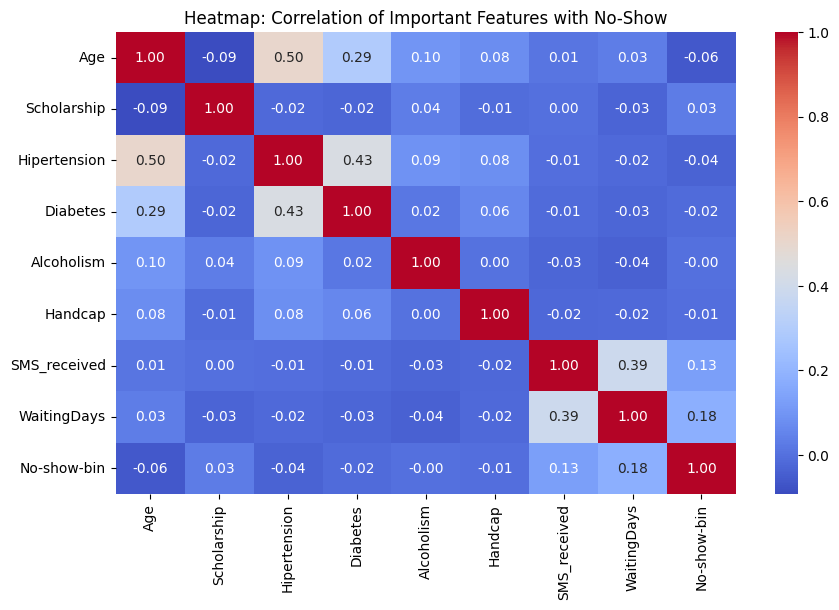

In [61]:
#HEAT MAP: IMPORTANT FEATURES

import seaborn as sns
import matplotlib.pyplot as plt

# Prepare numeric-only dataframe (encode target)
df_eda = df.copy()
df_eda['No-show-bin'] = df_eda['No-show'].map({'No': 0, 'Yes': 1})

numeric_cols = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'WaitingDays', 'No-show-bin']

corr = df_eda[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap: Correlation of Important Features with No-Show")
plt.show()

In [62]:
## Model 1: Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [64]:
log_reg_model = Pipeline(steps=[("preprocessor", preprocessor), ("smote", SMOTE(random_state=42)), ("classifier", LogisticRegression(max_iter=1000))])
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

In [65]:
print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Results
[[11803  5839]
 [ 1881  2583]]
              precision    recall  f1-score   support

           0       0.86      0.67      0.75     17642
           1       0.31      0.58      0.40      4464

    accuracy                           0.65     22106
   macro avg       0.58      0.62      0.58     22106
weighted avg       0.75      0.65      0.68     22106



In [66]:
## Model 2: Decision Tree

In [67]:
from sklearn.tree import DecisionTreeClassifier

In [68]:
tree_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", DecisionTreeClassifier(max_depth=5, random_state=42)) #other hyperparameters can be tuned as well.

    #find best values for max_depth, min_samples_split, min_samples_leaf using GridSearchCV or RandomizedSearchCV
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)


print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Results
[[9355 8287]
 [ 943 3521]]
              precision    recall  f1-score   support

           0       0.91      0.53      0.67     17642
           1       0.30      0.79      0.43      4464

    accuracy                           0.58     22106
   macro avg       0.60      0.66      0.55     22106
weighted avg       0.79      0.58      0.62     22106



In [69]:
import joblib

joblib.dump(log_reg_model, "model.joblib")

['model.joblib']

In [70]:
#comparsion of classification reports of both models

from sklearn.metrics import classification_report

# Predictions
y_pred_lr = log_reg_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)  # or best_tree_model if tuned

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_tree))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.86      0.67      0.75     17642
           1       0.31      0.58      0.40      4464

    accuracy                           0.65     22106
   macro avg       0.58      0.62      0.58     22106
weighted avg       0.75      0.65      0.68     22106

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.91      0.53      0.67     17642
           1       0.30      0.79      0.43      4464

    accuracy                           0.58     22106
   macro avg       0.60      0.66      0.55     22106
weighted avg       0.79      0.58      0.62     22106



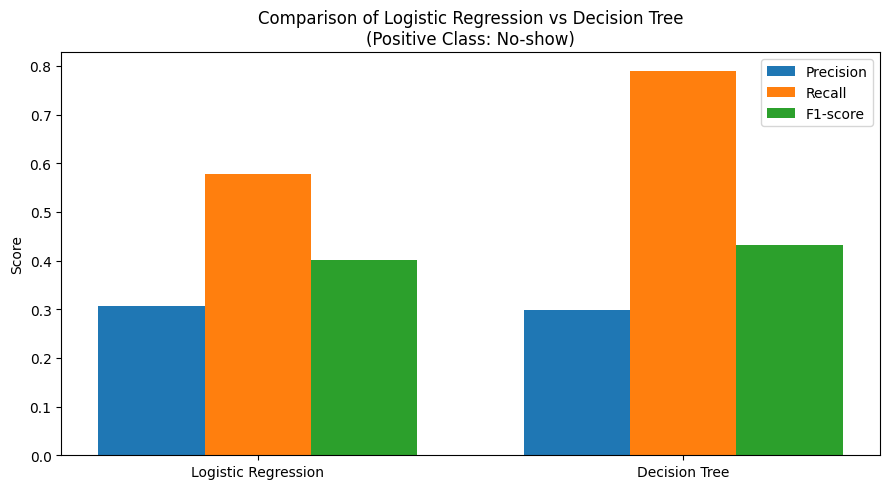

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Extract classification reports as dictionaries
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_tree = classification_report(y_test, y_pred_tree, output_dict=True)

# Extract positive class (1 = No-show) metrics
precision = [
    report_lr["1"]["precision"],
    report_tree["1"]["precision"]
]

recall = [
    report_lr["1"]["recall"],
    report_tree["1"]["recall"]
]

f1 = [
    report_lr["1"]["f1-score"],
    report_tree["1"]["f1-score"]
]

labels = ["Logistic Regression", "Decision Tree"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(9,5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Comparison of Logistic Regression vs Decision Tree\n(Positive Class: No-show)")
plt.legend()

plt.tight_layout()
plt.show()

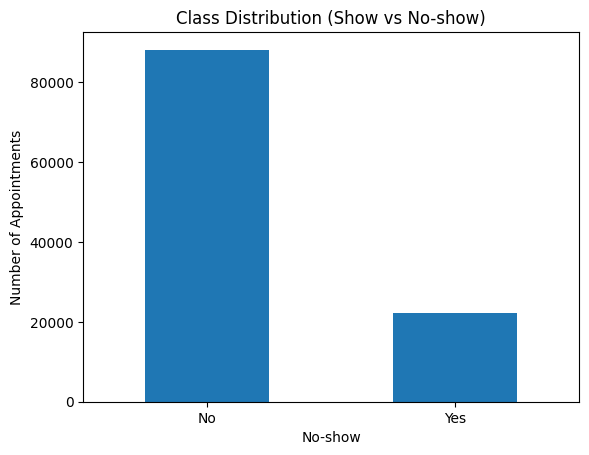

In [72]:
#Class Distribution in Training Set
import matplotlib.pyplot as plt

df['No-show'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Show vs No-show)")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.show()

In [73]:
import pandas as pd

def predict_risk(model, patient_data):
    
    if isinstance(patient_data, pd.Series):
        patient_data = pd.DataFrame([patient_data])
        
    prob = model.predict_proba(patient_data)[0][1]
    
    if prob > 0.7:
        risk = "High"
    elif prob > 0.4:
        risk = "Medium"
    else:
        risk = "Low"
    
    return prob, risk


In [74]:
# --- LangGraph Agent & FAISS RAG Definition ---
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from langchain_community.document_loaders import TextLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader = TextLoader("guidelines.txt")
docs = loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
splits = text_splitter.split_documents(docs)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(splits, embeddings)

class AgentState(TypedDict):
    patient_data: dict
    risk_level: str
    probability: float
    guidelines: str
    action_plan: str
    reasoning: str
    final_report: dict

def retrieve_guidelines(state: AgentState):
    query = f"Intervention protocol for {state['risk_level']} risk patient"
    docs = vectorstore.similarity_search(query, k=2)
    guidelines_text = "\n".join([doc.page_content for doc in docs])
    return {"guidelines": guidelines_text}

def clinical_reasoning(state: AgentState):
    try:
        api_key = os.environ.get("GROQ_API_KEY", "")
        llm = ChatGroq(temperature=0, model="llama-3.1-8b-instant", api_key=api_key)
        prompt = f"""
        You are an AI Clinical Operations Assistant.
        Perform a risk analysis and multi-step planning intervention for this patient based strictly on the provided guidelines.
        
        Patient Data: {state['patient_data']}
        Risk Level: {state['risk_level']} (Probability: {state['probability']:.2f})
        Retrieved Operational Guidelines: 
        {state['guidelines']}
        
        Format your response EXACTLY like this:
        SUMMARY: <Brief risk summary analysis>
        INTERVENTION: <Actionable multi-step intervention plan based on guidelines>
        """
        
        response = llm.invoke(prompt)
        content = response.content
        summary = content.split("INTERVENTION:")[0].replace("SUMMARY:", "").strip()
        intervention = content.split("INTERVENTION:")[1].strip()
    except Exception as e:
        summary = "Error performing risk analysis."
        intervention = f"Manual clinician review required. Error: {str(e)}"
        
    return {"action_plan": intervention, "reasoning": summary}

def generate_report(state: AgentState):
    report = {
        "Risk Summary": state["reasoning"],
        "Intervention": state["action_plan"],
        "Sources": state["guidelines"],
        "Disclaimer": "Operational and Ethical disclosures: AI-generated recommendation via LangGraph & FAISS RAG."
    }
    return {"final_report": report}

workflow = StateGraph(AgentState)
workflow.add_node("retrieve_guidelines", retrieve_guidelines)
workflow.add_node("clinical_reasoning", clinical_reasoning)
workflow.add_node("generate_report", generate_report)

workflow.set_entry_point("retrieve_guidelines")
workflow.add_edge("retrieve_guidelines", "clinical_reasoning")
workflow.add_edge("clinical_reasoning", "generate_report")
workflow.add_edge("generate_report", END)

app_graph = workflow.compile()


In [75]:
guidelines = {
    "High": "Patients with high no-show risk should receive phone calls and flexible rescheduling.",
    "Medium": "Send SMS reminders 24 hours before appointment.",
    "Low": "Standard scheduling is sufficient."
}

In [76]:
def generate_report(prob, risk, decision):
    return {
        "risk_level": risk,
        "probability": float(prob),
        "recommended_action": decision["action"],
        "reason": decision["reason"],
        "guideline": guidelines[risk],
        "disclaimer": "AI-generated recommendation. Final decision should be made by healthcare professionals."
    }

In [77]:
import json
# Example patient (adjust based on your dataset features)
sample_patient = X_test.iloc[0]

prob, risk = predict_risk(log_reg_model, sample_patient)

initial_state = {
    "patient_data": sample_patient.to_dict(),
    "risk_level": risk,
    "probability": prob
}

final_state = app_graph.invoke(initial_state)
report = final_state["final_report"]

print(json.dumps(report, indent=2))


{
  "risk_level": "Medium",
  "probability": 0.49562570583318466,
  "recommended_action": "Send SMS Reminder",
  "reason": "Moderate risk of missing appointment",
  "guideline": "Send SMS reminders 24 hours before appointment.",
  "disclaimer": "AI-generated recommendation. Final decision should be made by healthcare professionals."
}
